# 03 — AE/VAE finale su preprocessing pulito

Questo notebook allena **Autoencoder** e **Variational Autoencoder** usando il dataset aggregato prodotto dal notebook di preprocessing finale.

Obiettivo:

```text
train QCD/background → eval QCD/background indipendente → test QCD vs Emerging Jets
```

Il segnale **non entra mai** in training, normalizzazione o early stopping.

---

## Cosa viene preso dai notebook precedenti

| Notebook sorgente | Cosa viene riusato concettualmente | Perché |
|---|---|---|
| `clean_jet_track_AE_VAE_pipeline.ipynb` | struttura AE/VAE pulita, salvataggio score, confronto AE/VAE, metriche finali | era la pipeline Andrea più riproducibile |
| `02_autoencoder_locale.ipynb` | training QCD-only, score distribution, ROC, per-feature reconstruction error, score whitened | utile per interpretabilità e anomaly score più robusto |
| `03_vae_locale.ipynb` | VAE con reparameterization trick, clamp `logvar`, score latente/Mahalanobis | migliora la parte probabilistica del VAE |
| `07_autoencoder_feat.ipynb` | attenzione a leakage, LayerNorm/GELU, early stopping | utile per stabilità e difendibilità |
| `FINAL_preprocessing_with_eval.ipynb` | usa `repr1_aggregate.npz` con `bkg_train`, `bkg_eval`, `sig` | preprocessing nuovo, con `pp_output_eval` incluso |

**Importante:** questo notebook non rifà il preprocessing. Usa solo gli `.npz` già generati.


## 0. Setup

In [4]:
import sys
print(sys.executable)

c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Scripts\python.exe


In [5]:

from pathlib import Path
import json
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.12.0+cpu
Device: cpu


In [6]:

from pathlib import Path
import json
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.12.0+cpu
Device: cpu


## 1. Path e configurazione

Il notebook prova a trovare automaticamente la cartella `processed/` sia se viene lanciato da `FINAL/`, sia se viene lanciato da `FINAL/notebooks/`, sia se viene lanciato dalla root del repository.

In [7]:

# -----------------------------------------------------------------------------
# Path robusti
# -----------------------------------------------------------------------------
CANDIDATE_PROCESSED_DIRS = [
    Path("processed"),
    Path("../processed"),
    Path("FINAL/processed"),
    Path("../FINAL/processed"),
]

PROCESSED_DIR = None
for p in CANDIDATE_PROCESSED_DIRS:
    if (p / "repr1_aggregate.npz").exists():
        PROCESSED_DIR = p
        break

if PROCESSED_DIR is None:
    print("Non ho trovato automaticamente repr1_aggregate.npz.")
    print("Imposta manualmente PROCESSED_DIR nella cella sotto.")
    PROCESSED_DIR = Path("../processed")

OUTPUT_DIR = Path("../outputs/ae_vae")
if not OUTPUT_DIR.parent.exists():
    OUTPUT_DIR = Path("outputs/ae_vae")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


PROCESSED_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed
OUTPUT_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\notebooks\outputs\ae_vae


In [8]:

# -----------------------------------------------------------------------------
# Iperparametri principali
# -----------------------------------------------------------------------------
BATCH_SIZE = 1024
MAX_EPOCHS_AE = 500
MAX_EPOCHS_VAE = 500
PATIENCE = 15
LR = 1e-3
WEIGHT_DECAY = 1e-5

LATENT_DIM = 16
HIDDEN_DIMS = [128, 64]
DROPOUT = 0.05

# VAE: beta basso per anomaly detection tabulare, evita che la KL domini troppo.
BETA = 1e-3
LOGVAR_CLAMP = (-10.0, 10.0)

# Se repr1_aggregate e' gia' standardizzato, di solito non serve un secondo scaler.
# Il notebook controlla automaticamente e applica uno scaler solo se necessario.
AUTO_STANDARDIZE_IF_NEEDED = True

# Limite opzionale per debug veloce. Lascia None per usare tutto.
MAX_TRAIN = None
MAX_EVAL = None
MAX_SIG = None


## 2. Caricamento del dataset aggregato

Il preprocessing finale salva `repr1_aggregate.npz` con:

```text
bkg_train  = QCD/background per training
bkg_eval   = QCD/background indipendente per validazione/evaluation interna
sig        = Emerging Jets, usato solo per valutazione finale
```

Se in futuro si aggiunge anche un test background separato, il notebook lo userà automaticamente se presente come `bkg_test`.

In [9]:

def load_repr1_aggregate(processed_dir: Path):
    path = processed_dir / "repr1_aggregate.npz"
    if not path.exists():
        raise FileNotFoundError(f"Non trovo {path}. Devi prima eseguire il preprocessing finale.")

    data = np.load(path, allow_pickle=True)
    keys = set(data.files)
    print("File:", path)
    print("Keys:", sorted(keys))

    required = {"bkg_train", "bkg_eval", "sig"}
    missing = required - keys
    if missing:
        raise KeyError(f"Mancano keys obbligatorie in repr1_aggregate.npz: {missing}")

    X_train = data["bkg_train"].astype(np.float32)
    X_eval = data["bkg_eval"].astype(np.float32)
    X_sig = data["sig"].astype(np.float32)

    if "bkg_test" in keys:
        X_bg_test = data["bkg_test"].astype(np.float32)
        bg_test_name = "bkg_test"
    else:
        # Nel preprocessing con pp_output_eval non abbiamo un test QCD separato.
        # Usiamo bkg_eval come QCD indipendente per ROC. Va dichiarato nel report.
        X_bg_test = X_eval.copy()
        bg_test_name = "bkg_eval (usato anche come QCD di test)"

    if "feature_names" in keys:
        feature_names = [str(x) for x in data["feature_names"].tolist()]
    elif "aggregate_feature_names" in keys:
        feature_names = [str(x) for x in data["aggregate_feature_names"].tolist()]
    else:
        feature_names = [f"f{i}" for i in range(X_train.shape[1])]

    return X_train, X_eval, X_bg_test, X_sig, feature_names, bg_test_name

X_train, X_eval, X_bg, X_sig, feature_names, bg_test_name = load_repr1_aggregate(PROCESSED_DIR)

print("\nShapes:")
print("  train background:", X_train.shape)
print("  eval background :", X_eval.shape)
print("  final QCD bg    :", X_bg.shape, "<-", bg_test_name)
print("  signal EJ       :", X_sig.shape)
print("  n features      :", len(feature_names))


File: ..\processed\repr1_aggregate.npz
Keys: ['bkg_eval', 'bkg_train', 'feature_names', 'norm_mean', 'norm_std', 'sig']

Shapes:
  train background: (40000, 96)
  eval background : (40000, 96)
  final QCD bg    : (40000, 96) <- bkg_eval (usato anche come QCD di test)
  signal EJ       : (40000, 96)
  n features      : 96


## 3. Sanity check anti-leakage

Qui controlliamo che i nomi delle feature aggregate non contengano variabili proibite o sospette come input del modello.

In [10]:

LEAKY_TERMS = [
    "isdisplaced",
    "istagged",
    "salt_pdisp",
    "displacedptfraction",
    "flavour_label",
    "flavor_label",
    "truthoriginlabel",
    "truthvertexindex",
    "vsivertexindex",
    "truth_dark_pions",
    "truth_stable_non_geant",
    "eventnumber",
    "mceventweight",
    "averageinteractionspercrossing",
    "actualinteractionspercrossing",
    "nprimaryvertices",
    "isrun3",
]

bad = []
for name in feature_names:
    low = name.lower().replace(" ", "")
    if any(term in low for term in LEAKY_TERMS):
        bad.append(name)

if bad:
    raise ValueError("Feature potenzialmente leaky trovate negli input: " + str(bad))
else:
    print("OK: nessuna feature leaky trovata nei nomi delle feature aggregate.")

print("Prime 20 feature:")
for f in feature_names[:20]:
    print(" -", f)


OK: nessuna feature leaky trovata nei nomi delle feature aggregate.
Prime 20 feature:
 - pt
 - eta
 - mass
 - energy
 - Qw_clusterSoftDrop
 - C2_clusterSoftDrop
 - D2_clusterSoftDrop
 - Tau1_clusterSoftDrop
 - Tau2_clusterSoftDrop
 - Tau3_clusterSoftDrop
 - Tau4_clusterSoftDrop
 - Tau21_clusterSoftDrop
 - Tau32_clusterSoftDrop
 - ECF1_clusterSoftDrop
 - ECF2_clusterSoftDrop
 - log_n_tracks
 - pt_log1p_mean
 - d0_log1p_mean
 - z0SinTheta_mean
 - deta_mean


## 4. Pulizia numerica e standardizzazione opzionale

`repr1_aggregate.npz` dovrebbe essere già standardizzato dal preprocessing su QCD train. Qui facciamo solo un controllo. Se non sembra standardizzato, applichiamo uno scaler calcolato **solo su train background**.

In [11]:

def clean_finite(X, name):
    X = np.asarray(X, dtype=np.float32)
    n_bad = np.size(X) - np.isfinite(X).sum()
    if n_bad > 0:
        print(f"[WARN] {name}: sostituisco {n_bad} NaN/Inf con 0.")
    return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

X_train = clean_finite(X_train, "X_train")
X_eval = clean_finite(X_eval, "X_eval")
X_bg = clean_finite(X_bg, "X_bg")
X_sig = clean_finite(X_sig, "X_sig")

# Subsampling opzionale, utile per prove veloci su CPU.
def maybe_subsample(X, max_n, seed=42):
    if max_n is None or len(X) <= max_n:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=max_n, replace=False)
    return X[idx]

X_train = maybe_subsample(X_train, MAX_TRAIN, SEED)
X_eval = maybe_subsample(X_eval, MAX_EVAL, SEED + 1)
X_bg = maybe_subsample(X_bg, MAX_EVAL, SEED + 2)
X_sig = maybe_subsample(X_sig, MAX_SIG, SEED + 3)

train_mean_check = np.nanmedian(np.abs(X_train.mean(axis=0)))
train_std_med = np.nanmedian(X_train.std(axis=0))
print("Median |mean_train|:", train_mean_check)
print("Median std_train   :", train_std_med)

SCALER_INFO = {"applied": False}

need_scaler = (
    AUTO_STANDARDIZE_IF_NEEDED
    and (train_mean_check > 0.20 or train_std_med < 0.50 or train_std_med > 2.00)
)

if need_scaler:
    print("Applico scaler finale calcolato solo su train background.")
    mu = X_train.mean(axis=0)
    sd = X_train.std(axis=0)
    sd = np.where(sd < 1e-6, 1.0, sd)
    X_train = (X_train - mu) / sd
    X_eval = (X_eval - mu) / sd
    X_bg = (X_bg - mu) / sd
    X_sig = (X_sig - mu) / sd
    SCALER_INFO = {
        "applied": True,
        "mean": mu.astype(float).tolist(),
        "std": sd.astype(float).tolist(),
    }
else:
    print("Non applico scaler aggiuntivo: il dataset sembra gia' normalizzato.")

print("\nFinal shapes:")
print(X_train.shape, X_eval.shape, X_bg.shape, X_sig.shape)


Median |mean_train|: 3.758435e-06
Median std_train   : 1.0
Non applico scaler aggiuntivo: il dataset sembra gia' normalizzato.

Final shapes:
(40000, 96) (40000, 96) (40000, 96) (40000, 96)


## 5. Dataset e DataLoader

In [12]:

def make_loader(X, batch_size=BATCH_SIZE, shuffle=False):
    tensor = torch.from_numpy(X.astype(np.float32))
    ds = TensorDataset(tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

train_loader = make_loader(X_train, shuffle=True)
eval_loader = make_loader(X_eval, shuffle=False)

input_dim = X_train.shape[1]
print("input_dim:", input_dim)
print("n train batches:", len(train_loader))
print("n eval batches :", len(eval_loader))


input_dim: 96
n train batches: 40
n eval batches : 40


## 6. Modelli: Autoencoder e VAE

Architettura MLP compatta:

```text
input_dim → 128 → 64 → latent_dim → 64 → 128 → input_dim
```

Uso `LayerNorm + GELU + Dropout` per stabilità numerica.

In [13]:

class MLPBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64), latent_dim=16, dropout=0.05):
        super().__init__()
        enc = []
        prev = input_dim
        for h in hidden_dims:
            enc.append(MLPBlock(prev, h, dropout))
            prev = h
        enc.append(nn.Linear(prev, latent_dim))
        self.encoder = nn.Sequential(*enc)

        dec = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec.append(MLPBlock(prev, h, dropout))
            prev = h
        dec.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec)

    def forward(self, x):
        z = self.encoder(x)
        xhat = self.decoder(z)
        return xhat, z


class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64), latent_dim=16, dropout=0.05, logvar_clamp=(-10, 10)):
        super().__init__()
        self.logvar_clamp = logvar_clamp

        enc = []
        prev = input_dim
        for h in hidden_dims:
            enc.append(MLPBlock(prev, h, dropout))
            prev = h
        self.encoder = nn.Sequential(*enc)
        self.mu = nn.Linear(prev, latent_dim)
        self.logvar = nn.Linear(prev, latent_dim)

        dec = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec.append(MLPBlock(prev, h, dropout))
            prev = h
        dec.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec)

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h).clamp(*self.logvar_clamp)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, sample=True):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar) if sample else mu
        xhat = self.decoder(z)
        return xhat, mu, logvar, z


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

ae = Autoencoder(input_dim, HIDDEN_DIMS, LATENT_DIM, DROPOUT).to(device)
vae = VAE(input_dim, HIDDEN_DIMS, LATENT_DIM, DROPOUT, LOGVAR_CLAMP).to(device)

print(ae)
print("AE trainable params:", count_params(ae))
print("VAE trainable params:", count_params(vae))


Autoencoder(
  (encoder): Sequential(
    (0): MLPBlock(
      (net): Sequential(
        (0): Linear(in_features=96, out_features=128, bias=True)
        (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.05, inplace=False)
      )
    )
    (1): MLPBlock(
      (net): Sequential(
        (0): Linear(in_features=128, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.05, inplace=False)
      )
    )
    (2): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): MLPBlock(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.05, inplace=False)
      )
    )
    (1): MLPBlock(
      (n

## 7. Training utilities

In [14]:

class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.counter = 0
        self.best_state = None

    def step(self, value, model):
        if value < self.best - self.min_delta:
            self.best = value
            self.counter = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience


def eval_ae_loss(model, loader):
    model.eval()
    losses = []
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            xhat, _ = model(x)
            loss = F.mse_loss(xhat, x, reduction="mean")
            losses.append(loss.item())
    return float(np.mean(losses))


def vae_loss_terms(xhat, x, mu, logvar, beta=BETA):
    reco = F.mse_loss(xhat, x, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = reco + beta * kl
    return total, reco, kl


def eval_vae_loss(model, loader, beta=BETA):
    model.eval()
    totals, recos, kls = [], [], []
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            xhat, mu, logvar, _ = model(x, sample=False)
            total, reco, kl = vae_loss_terms(xhat, x, mu, logvar, beta)
            totals.append(total.item())
            recos.append(reco.item())
            kls.append(kl.item())
    return float(np.mean(totals)), float(np.mean(recos)), float(np.mean(kls))


## 8. Training Autoencoder

In [15]:

def train_autoencoder(model, train_loader, eval_loader, max_epochs=MAX_EPOCHS_AE):
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    early = EarlyStopping(patience=PATIENCE)
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for (x,) in train_loader:
            x = x.to(device)
            opt.zero_grad()
            xhat, _ = model(x)
            loss = F.mse_loss(xhat, x, reduction="mean")
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        eval_loss = eval_ae_loss(model, eval_loader)
        scheduler.step(eval_loss)
        history.append({"epoch": epoch, "train_loss": train_loss, "eval_loss": eval_loss})

        if epoch == 1 or epoch % 10 == 0:
            print(f"[AE] epoch {epoch:03d} | train={train_loss:.6f} | eval={eval_loss:.6f}")

        if early.step(eval_loss, model):
            print(f"[AE] early stopping at epoch {epoch}, best eval={early.best:.6f}")
            break

    if early.best_state is not None:
        model.load_state_dict(early.best_state)
    return pd.DataFrame(history)

hist_ae = train_autoencoder(ae, train_loader, eval_loader)


[AE] epoch 001 | train=0.793123 | eval=0.576565
[AE] epoch 010 | train=0.324997 | eval=0.271685
[AE] epoch 020 | train=0.275918 | eval=0.233143
[AE] epoch 030 | train=0.249387 | eval=0.209984
[AE] epoch 040 | train=0.237869 | eval=0.199971
[AE] epoch 050 | train=0.231079 | eval=0.193534
[AE] epoch 060 | train=0.226857 | eval=0.189480
[AE] epoch 070 | train=0.223432 | eval=0.185881
[AE] epoch 080 | train=0.221180 | eval=0.183768
[AE] epoch 090 | train=0.219349 | eval=0.181811
[AE] epoch 100 | train=0.216986 | eval=0.180807
[AE] epoch 110 | train=0.217249 | eval=0.179444
[AE] epoch 120 | train=0.215831 | eval=0.177965
[AE] epoch 130 | train=0.215247 | eval=0.177865
[AE] epoch 140 | train=0.214405 | eval=0.176081
[AE] epoch 150 | train=0.213856 | eval=0.175605
[AE] epoch 160 | train=0.213276 | eval=0.174862
[AE] epoch 170 | train=0.212668 | eval=0.173882
[AE] epoch 180 | train=0.211161 | eval=0.173603
[AE] epoch 190 | train=0.209661 | eval=0.172206
[AE] epoch 200 | train=0.209572 | eval=0

## 9. Training VAE

In [16]:

def train_vae(model, train_loader, eval_loader, max_epochs=MAX_EPOCHS_VAE, beta=BETA):
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    early = EarlyStopping(patience=PATIENCE)
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        totals, recos, kls = [], [], []
        for (x,) in train_loader:
            x = x.to(device)
            opt.zero_grad()
            xhat, mu, logvar, _ = model(x, sample=True)
            total, reco, kl = vae_loss_terms(xhat, x, mu, logvar, beta)
            total.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()
            totals.append(total.item())
            recos.append(reco.item())
            kls.append(kl.item())

        train_total = float(np.mean(totals))
        train_reco = float(np.mean(recos))
        train_kl = float(np.mean(kls))
        eval_total, eval_reco, eval_kl = eval_vae_loss(model, eval_loader, beta)
        scheduler.step(eval_total)

        history.append({
            "epoch": epoch,
            "train_total": train_total,
            "train_reco": train_reco,
            "train_kl": train_kl,
            "eval_total": eval_total,
            "eval_reco": eval_reco,
            "eval_kl": eval_kl,
        })

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"[VAE] epoch {epoch:03d} | "
                f"train={train_total:.6f} | eval={eval_total:.6f} | "
                f"eval_reco={eval_reco:.6f} | eval_kl={eval_kl:.6f}"
            )

        if early.step(eval_total, model):
            print(f"[VAE] early stopping at epoch {epoch}, best eval={early.best:.6f}")
            break

    if early.best_state is not None:
        model.load_state_dict(early.best_state)
    return pd.DataFrame(history)

hist_vae = train_vae(vae, train_loader, eval_loader)


[VAE] epoch 001 | train=0.875122 | eval=0.675949 | eval_reco=0.675142 | eval_kl=0.807014
[VAE] epoch 010 | train=0.361110 | eval=0.313109 | eval_reco=0.309951 | eval_kl=3.157655
[VAE] epoch 020 | train=0.300865 | eval=0.251537 | eval_reco=0.248054 | eval_kl=3.483072
[VAE] epoch 030 | train=0.275236 | eval=0.227844 | eval_reco=0.224307 | eval_kl=3.536857
[VAE] epoch 040 | train=0.261420 | eval=0.216586 | eval_reco=0.212997 | eval_kl=3.589559
[VAE] epoch 050 | train=0.252555 | eval=0.207695 | eval_reco=0.203972 | eval_kl=3.723398
[VAE] epoch 060 | train=0.245884 | eval=0.202277 | eval_reco=0.198397 | eval_kl=3.880272
[VAE] epoch 070 | train=0.238088 | eval=0.194111 | eval_reco=0.189829 | eval_kl=4.282814
[VAE] epoch 080 | train=0.231666 | eval=0.189647 | eval_reco=0.185038 | eval_kl=4.609155
[VAE] epoch 090 | train=0.227543 | eval=0.188117 | eval_reco=0.183538 | eval_kl=4.579159
[VAE] epoch 100 | train=0.224849 | eval=0.182758 | eval_reco=0.178191 | eval_kl=4.567432
[VAE] epoch 110 | tra

## 10. Curve di training

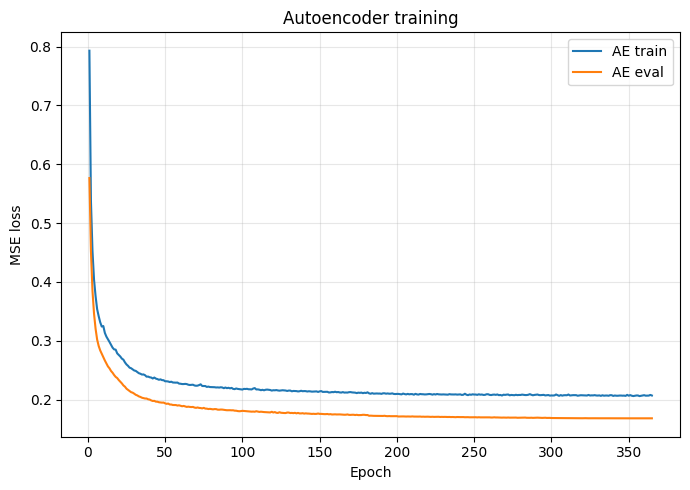

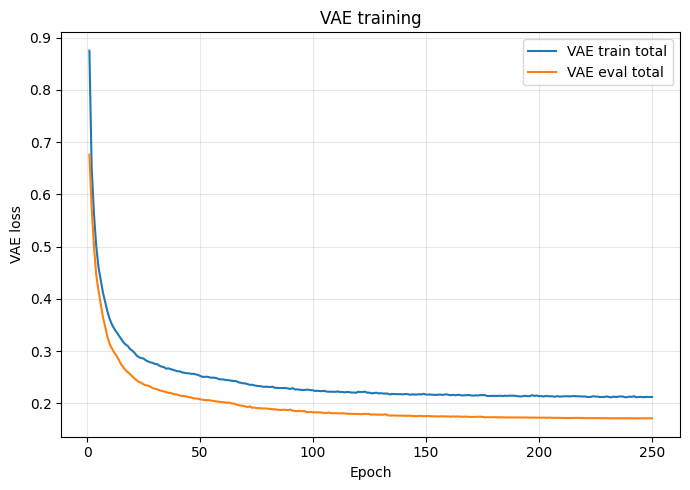

In [17]:

plt.figure(figsize=(7, 5))
plt.plot(hist_ae["epoch"], hist_ae["train_loss"], label="AE train")
plt.plot(hist_ae["epoch"], hist_ae["eval_loss"], label="AE eval")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Autoencoder training")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "ae_training_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(hist_vae["epoch"], hist_vae["train_total"], label="VAE train total")
plt.plot(hist_vae["epoch"], hist_vae["eval_total"], label="VAE eval total")
plt.xlabel("Epoch")
plt.ylabel("VAE loss")
plt.title("VAE training")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "vae_training_curve.png", dpi=200)
plt.show()


## 11. Calcolo anomaly score

Salviamo più score:

### AE
- `ae_mse`: MSE medio.
- `ae_whitened`: errore per feature pesato con la varianza dell'errore su QCD eval.

### VAE
- `vae_reco`: MSE medio.
- `vae_kl`: termine KL.
- `vae_total`: `reco + beta * KL`.
- `vae_official`: reconstruction whitened + distanza latente standardizzata.


In [18]:

def batch_predict_ae(model, X, batch_size=BATCH_SIZE):
    model.eval()
    xs, xhats, zs = [], [], []
    loader = make_loader(X, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            xhat, z = model(x)
            xs.append(x.cpu().numpy())
            xhats.append(xhat.cpu().numpy())
            zs.append(z.cpu().numpy())
    return np.concatenate(xs), np.concatenate(xhats), np.concatenate(zs)


def batch_predict_vae(model, X, batch_size=BATCH_SIZE):
    model.eval()
    xs, xhats, mus, logvars = [], [], [], []
    loader = make_loader(X, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            xhat, mu, logvar, _ = model(x, sample=False)
            xs.append(x.cpu().numpy())
            xhats.append(xhat.cpu().numpy())
            mus.append(mu.cpu().numpy())
            logvars.append(logvar.cpu().numpy())
    return np.concatenate(xs), np.concatenate(xhats), np.concatenate(mus), np.concatenate(logvars)


def ae_scores_from_reco(X, Xhat, err_scale=None):
    err = (X - Xhat) ** 2
    mse = err.mean(axis=1)
    if err_scale is None:
        white = mse.copy()
    else:
        white = (err / err_scale).mean(axis=1)
    return mse.astype(np.float32), white.astype(np.float32), err


def kl_from_mu_logvar(mu, logvar):
    kl_per_dim = -0.5 * (1 + logvar - mu ** 2 - np.exp(logvar))
    return kl_per_dim.mean(axis=1).astype(np.float32)


def zscore_with_eval(x, eval_x):
    mu = np.mean(eval_x)
    sd = np.std(eval_x)
    if sd < 1e-8:
        sd = 1.0
    return (x - mu) / sd

# AE predictions
Xtr_ae, Xh_tr_ae, Ztr_ae = batch_predict_ae(ae, X_train)
Xev_ae, Xh_ev_ae, Zev_ae = batch_predict_ae(ae, X_eval)
Xbg_ae, Xh_bg_ae, Zbg_ae = batch_predict_ae(ae, X_bg)
Xsg_ae, Xh_sg_ae, Zsg_ae = batch_predict_ae(ae, X_sig)

# Errore medio per feature su eval QCD: usato per whitening dello score AE
_, _, err_eval_ae = ae_scores_from_reco(Xev_ae, Xh_ev_ae)
ae_err_scale = err_eval_ae.mean(axis=0) + 1e-8

ae_train_mse, ae_train_white, ae_err_train = ae_scores_from_reco(Xtr_ae, Xh_tr_ae, ae_err_scale)
ae_eval_mse, ae_eval_white, ae_err_eval = ae_scores_from_reco(Xev_ae, Xh_ev_ae, ae_err_scale)
ae_bg_mse, ae_bg_white, ae_err_bg = ae_scores_from_reco(Xbg_ae, Xh_bg_ae, ae_err_scale)
ae_sig_mse, ae_sig_white, ae_err_sig = ae_scores_from_reco(Xsg_ae, Xh_sg_ae, ae_err_scale)

# VAE predictions
Xtr_v, Xh_tr_v, Mu_tr, Lv_tr = batch_predict_vae(vae, X_train)
Xev_v, Xh_ev_v, Mu_ev, Lv_ev = batch_predict_vae(vae, X_eval)
Xbg_v, Xh_bg_v, Mu_bg, Lv_bg = batch_predict_vae(vae, X_bg)
Xsg_v, Xh_sg_v, Mu_sg, Lv_sg = batch_predict_vae(vae, X_sig)

_, _, err_eval_vae = ae_scores_from_reco(Xev_v, Xh_ev_v)
vae_err_scale = err_eval_vae.mean(axis=0) + 1e-8

vae_train_reco, vae_train_white, vae_err_train = ae_scores_from_reco(Xtr_v, Xh_tr_v, vae_err_scale)
vae_eval_reco, vae_eval_white, vae_err_eval = ae_scores_from_reco(Xev_v, Xh_ev_v, vae_err_scale)
vae_bg_reco, vae_bg_white, vae_err_bg = ae_scores_from_reco(Xbg_v, Xh_bg_v, vae_err_scale)
vae_sig_reco, vae_sig_white, vae_err_sig = ae_scores_from_reco(Xsg_v, Xh_sg_v, vae_err_scale)

vae_train_kl = kl_from_mu_logvar(Mu_tr, Lv_tr)
vae_eval_kl = kl_from_mu_logvar(Mu_ev, Lv_ev)
vae_bg_kl = kl_from_mu_logvar(Mu_bg, Lv_bg)
vae_sig_kl = kl_from_mu_logvar(Mu_sg, Lv_sg)

vae_train_total = vae_train_reco + BETA * vae_train_kl
vae_eval_total = vae_eval_reco + BETA * vae_eval_kl
vae_bg_total = vae_bg_reco + BETA * vae_bg_kl
vae_sig_total = vae_sig_reco + BETA * vae_sig_kl

# Latent anomaly: distanza diagonale tipo Mahalanobis rispetto a QCD eval
mu0 = Mu_ev.mean(axis=0)
s0 = Mu_ev.std(axis=0)
s0 = np.where(s0 < 1e-6, 1.0, s0)

def latent_diag_maha(Mu):
    return (((Mu - mu0) / s0) ** 2).mean(axis=1).astype(np.float32)

lat_train = latent_diag_maha(Mu_tr)
lat_eval = latent_diag_maha(Mu_ev)
lat_bg = latent_diag_maha(Mu_bg)
lat_sig = latent_diag_maha(Mu_sg)

# Score official VAE: somma di componenti standardizzate rispetto a eval QCD
vae_train_official = zscore_with_eval(vae_train_white, vae_eval_white) + zscore_with_eval(lat_train, lat_eval)
vae_eval_official = zscore_with_eval(vae_eval_white, vae_eval_white) + zscore_with_eval(lat_eval, lat_eval)
vae_bg_official = zscore_with_eval(vae_bg_white, vae_eval_white) + zscore_with_eval(lat_bg, lat_eval)
vae_sig_official = zscore_with_eval(vae_sig_white, vae_eval_white) + zscore_with_eval(lat_sig, lat_eval)

print("Score calcolati.")
print("AE white bg/sig mean:", ae_bg_white.mean(), ae_sig_white.mean())
print("VAE official bg/sig mean:", vae_bg_official.mean(), vae_sig_official.mean())


Score calcolati.
AE white bg/sig mean: 0.990426 4.918637
VAE official bg/sig mean: 4.7683715e-09 5.845136


## 12. Metriche: ROC/AUC, efficienza a mistag fissato, background check

In [19]:

def orient_scores(bg_scores, sig_scores):
    # Rende lo score orientato: valore alto = piu signal-like.
    y = np.concatenate([np.zeros_like(bg_scores), np.ones_like(sig_scores)])
    s = np.concatenate([bg_scores, sig_scores])
    auc = roc_auc_score(y, s)
    if auc < 0.5:
        return -bg_scores, -sig_scores, 1.0 - auc, True
    return bg_scores, sig_scores, auc, False


def eff_at_mistag(bg_scores, sig_scores, mistag):
    threshold = np.quantile(bg_scores, 1.0 - mistag)
    eff = np.mean(sig_scores >= threshold)
    return float(eff), float(threshold)


def bg_consistency_auc(train_scores, eval_scores):
    n = min(len(train_scores), len(eval_scores))
    rng = np.random.default_rng(SEED)
    tr = train_scores[rng.choice(len(train_scores), size=n, replace=False)]
    ev = eval_scores[rng.choice(len(eval_scores), size=n, replace=False)]
    y = np.concatenate([np.zeros(n), np.ones(n)])
    s = np.concatenate([tr, ev])
    auc = roc_auc_score(y, s)
    return max(float(auc), float(1.0 - auc))


def evaluate_score(name, train_scores, eval_scores, bg_scores, sig_scores):
    bg_o, sig_o, auc, flipped = orient_scores(bg_scores, sig_scores)
    train_o = -train_scores if flipped else train_scores
    eval_o = -eval_scores if flipped else eval_scores

    fpr, tpr, _ = roc_curve(
        np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)]),
        np.concatenate([bg_o, sig_o]),
    )

    row = {
        "model": name,
        "auc": float(auc),
        "flipped_score": bool(flipped),
        "train_vs_eval_bg_auc": bg_consistency_auc(train_o, eval_o),
    }
    for m in [0.30, 0.10, 0.05, 0.01, 0.001]:
        eff, thr = eff_at_mistag(bg_o, sig_o, m)
        row[f"eff_at_{m:g}_mistag"] = eff
        row[f"threshold_at_{m:g}_mistag"] = thr

    return row, fpr, tpr, bg_o, sig_o, train_o, eval_o

SCORES = {
    "AE MSE": (ae_train_mse, ae_eval_mse, ae_bg_mse, ae_sig_mse),
    "AE whitened": (ae_train_white, ae_eval_white, ae_bg_white, ae_sig_white),
    "VAE reco": (vae_train_reco, vae_eval_reco, vae_bg_reco, vae_sig_reco),
    "VAE KL": (vae_train_kl, vae_eval_kl, vae_bg_kl, vae_sig_kl),
    "VAE total": (vae_train_total, vae_eval_total, vae_bg_total, vae_sig_total),
    "VAE official": (vae_train_official, vae_eval_official, vae_bg_official, vae_sig_official),
}

results = []
curves = {}
oriented_scores = {}

for name, vals in SCORES.items():
    row, fpr, tpr, bg_o, sig_o, train_o, eval_o = evaluate_score(name, *vals)
    results.append(row)
    curves[name] = (fpr, tpr)
    oriented_scores[name] = {
        "train": train_o,
        "eval": eval_o,
        "bg": bg_o,
        "sig": sig_o,
    }

df_results = pd.DataFrame(results).sort_values("auc", ascending=False)
display(df_results)


,model,auc,flipped_score,train_vs_eval_bg_auc,eff_at_0.3_mistag,threshold_at_0.3_mistag,eff_at_0.1_mistag,threshold_at_0.1_mistag,eff_at_0.05_mistag,threshold_at_0.05_mistag,eff_at_0.01_mistag,threshold_at_0.01_mistag,eff_at_0.001_mistag,threshold_at_0.001_mistag
5,VAE official,0.857464,False,0.500382,0.853975,0.112703,0.570125,1.202575,0.390025,2.049249,0.149725,4.722008,0.041450,15.292325
1,AE whitened,0.855645,False,0.507931,0.841975,1.039558,0.594375,1.470472,0.441100,1.788206,0.171025,2.990936,0.036325,11.423558
4,VAE total,0.834587,False,0.506970,0.802275,0.186387,0.549975,0.253098,0.413650,0.298543,0.201875,0.430098,0.063250,0.817541
2,VAE reco,0.834520,False,0.506972,0.802250,0.181808,0.549875,0.248554,0.413800,0.293900,0.201775,0.425566,0.063225,0.813008
0,AE MSE,0.825389,False,0.508057,0.789000,0.184131,0.531400,0.249353,0.387500,0.294997,0.175925,0.421185,0.062025,0.789189
3,VAE KL,0.770340,False,0.503436,0.703525,4.564880,0.387000,4.610301,0.253975,4.643320,0.079975,4.747036,0.018675,4.956639


## 13. Plot finali AE/VAE

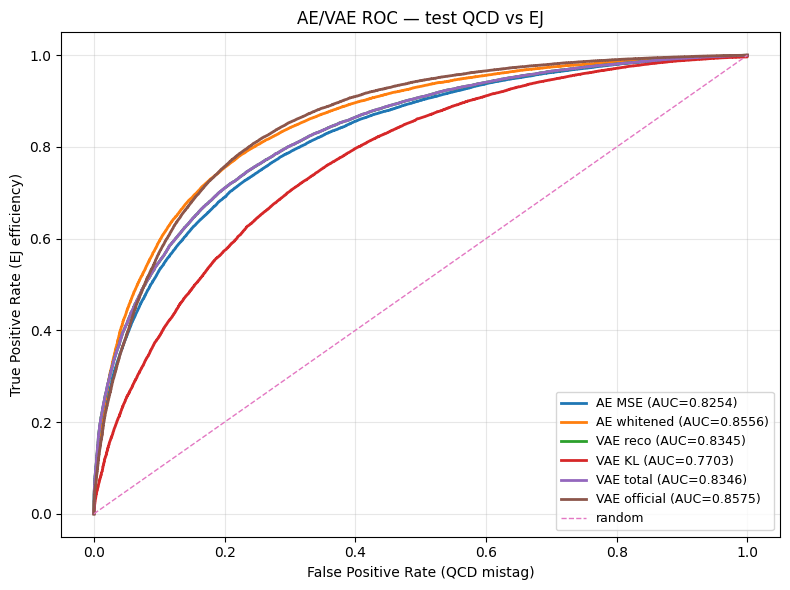

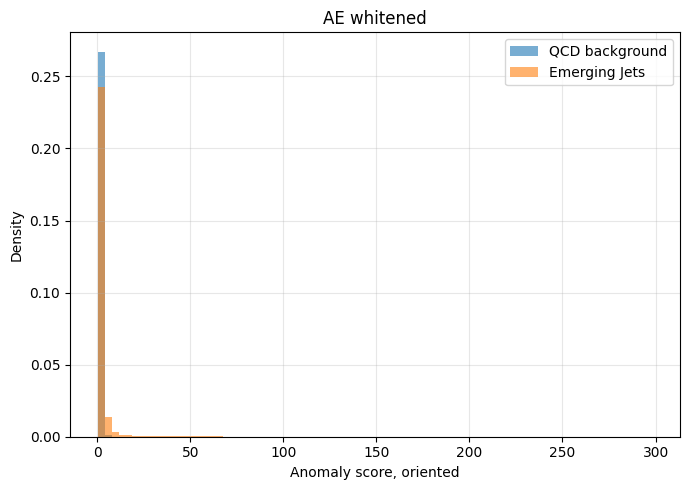

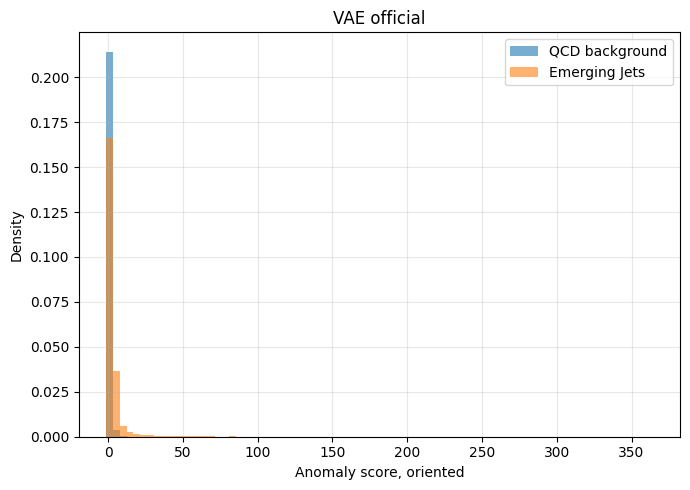

In [20]:

# ROC curves
plt.figure(figsize=(8, 6))
for name, (fpr, tpr) in curves.items():
    auc = df_results.loc[df_results["model"] == name, "auc"].values[0]
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], "--", linewidth=1, label="random")
plt.xlabel("False Positive Rate (QCD mistag)")
plt.ylabel("True Positive Rate (EJ efficiency)")
plt.title("AE/VAE ROC — test QCD vs EJ")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "ae_vae_roc.png", dpi=250)
plt.show()

# Score distributions per score migliore AE e VAE official
for name in ["AE whitened", "VAE official"]:
    bg = oriented_scores[name]["bg"]
    sig = oriented_scores[name]["sig"]
    lo = np.quantile(np.concatenate([bg, sig]), 0.001)
    hi = np.quantile(np.concatenate([bg, sig]), 0.999)
    plt.figure(figsize=(7, 5))
    plt.hist(bg, bins=80, range=(lo, hi), density=True, alpha=0.6, label="QCD background")
    plt.hist(sig, bins=80, range=(lo, hi), density=True, alpha=0.6, label="Emerging Jets")
    plt.xlabel("Anomaly score, oriented")
    plt.ylabel("Density")
    plt.title(name)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    safe = name.lower().replace(" ", "_")
    plt.savefig(OUTPUT_DIR / "plots" / f"score_distribution_{safe}.png", dpi=250)
    plt.show()


## 14. Per-feature reconstruction error

Questo plot aiuta a capire quali feature aggregate guidano l'anomaly score.

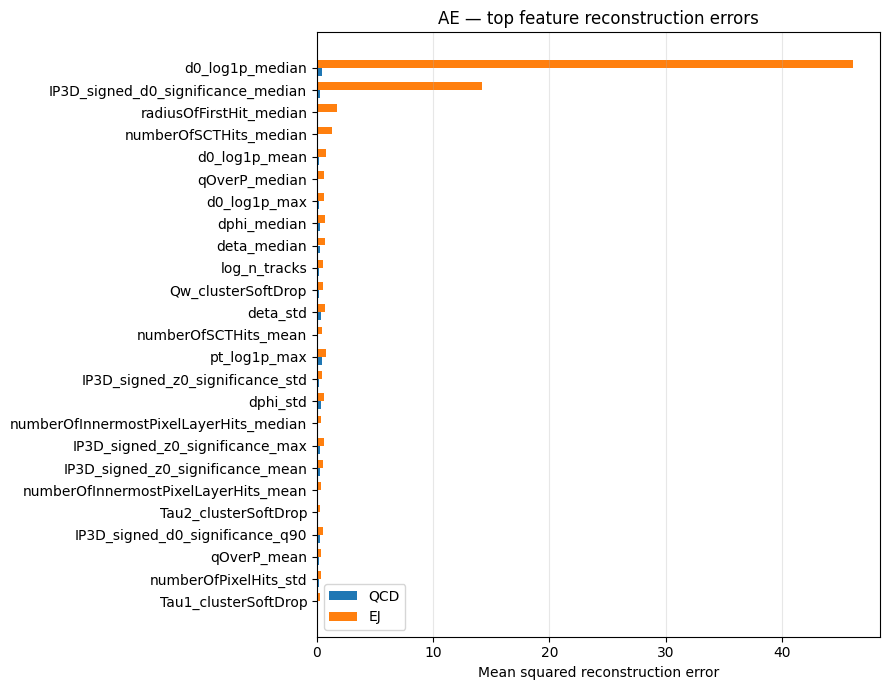

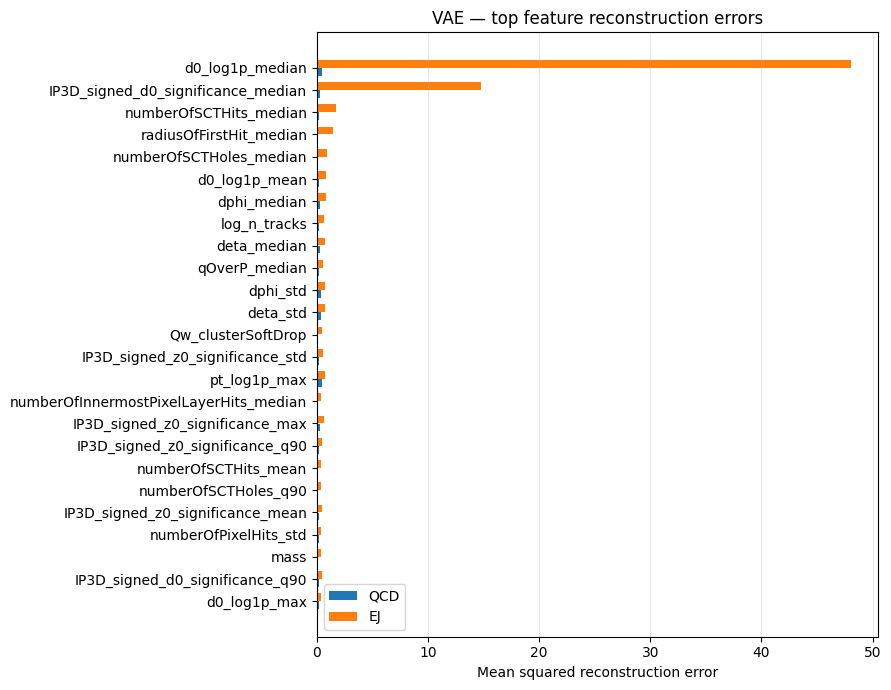

In [21]:

def plot_top_feature_errors(err_bg, err_sig, title, filename, top_k=25):
    diff = err_sig.mean(axis=0) - err_bg.mean(axis=0)
    order = np.argsort(diff)[-top_k:]
    labels = [feature_names[i] for i in order]

    plt.figure(figsize=(9, max(5, 0.28 * top_k)))
    y = np.arange(top_k)
    plt.barh(y - 0.18, err_bg.mean(axis=0)[order], height=0.35, label="QCD")
    plt.barh(y + 0.18, err_sig.mean(axis=0)[order], height=0.35, label="EJ")
    plt.yticks(y, labels)
    plt.xlabel("Mean squared reconstruction error")
    plt.title(title)
    plt.grid(True, axis="x", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "plots" / filename, dpi=250)
    plt.show()

plot_top_feature_errors(ae_err_bg, ae_err_sig, "AE — top feature reconstruction errors", "ae_top_feature_errors.png")
plot_top_feature_errors(vae_err_bg, vae_err_sig, "VAE — top feature reconstruction errors", "vae_top_feature_errors.png")


## 15. Salvataggio output

Questi output saranno poi caricati dal notebook Task 3 finale.

In [ ]:

# Salva modelli
model_config = {
    "input_dim": int(input_dim),
    "hidden_dims": HIDDEN_DIMS,
    "latent_dim": LATENT_DIM,
    "dropout": DROPOUT,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "beta": BETA,
    "logvar_clamp": LOGVAR_CLAMP,
    "seed": SEED,
    "processed_dir": str(PROCESSED_DIR),
    "bg_test_name": bg_test_name,
    "scaler_info": SCALER_INFO,
}

torch.save({"state_dict": ae.state_dict(), "config": model_config}, OUTPUT_DIR / "ae_model.pt")
torch.save({"state_dict": vae.state_dict(), "config": model_config}, OUTPUT_DIR / "vae_model.pt")

# Salva risultati tabellari
df_results.to_csv(OUTPUT_DIR / "ae_vae_results.csv", index=False)
hist_ae.to_csv(OUTPUT_DIR / "ae_training_history.csv", index=False)
hist_vae.to_csv(OUTPUT_DIR / "vae_training_history.csv", index=False)

with open(OUTPUT_DIR / "ae_vae_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

with open(OUTPUT_DIR / "aggregate_feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

# Salva tutti gli score, compresi quelli orientati.
np.savez_compressed(
    OUTPUT_DIR / "ae_vae_scores.npz",
    # raw AE 
    ae_scores_train_mse=ae_train_mse,
    ae_scores_eval_mse=ae_eval_mse,
    ae_scores_bg_mse=ae_bg_mse,
    ae_scores_sig_mse=ae_sig_mse,
    ae_scores_train_whitened=ae_train_white,
    ae_scores_eval_whitened=ae_eval_white,
    ae_scores_bg_whitened=ae_bg_white,
    ae_scores_sig_whitened=ae_sig_white,
    # raw VAE
    vae_scores_train_reco=vae_train_reco,
    vae_scores_eval_reco=vae_eval_reco,
    vae_scores_bg_reco=vae_bg_reco,
    vae_scores_sig_reco=vae_sig_reco,
    vae_scores_train_kl=vae_train_kl,
    vae_scores_eval_kl=vae_eval_kl,
    vae_scores_bg_kl=vae_bg_kl,
    vae_scores_sig_kl=vae_sig_kl,
    vae_scores_train_total=vae_train_total,
    vae_scores_eval_total=vae_eval_total,
    vae_scores_bg_total=vae_bg_total,
    vae_scores_sig_total=vae_sig_total,
    vae_scores_train_official=vae_train_official,
    vae_scores_eval_official=vae_eval_official,
    vae_scores_bg_official=vae_bg_official,
    vae_scores_sig_official=vae_sig_official,
    # oriented scores for easy Task 3 loading
    ae_oriented_train=oriented_scores["AE whitened"]["train"],
    ae_oriented_eval=oriented_scores["AE whitened"]["eval"],
    ae_oriented_bg=oriented_scores["AE whitened"]["bg"],
    ae_oriented_sig=oriented_scores["AE whitened"]["sig"],
    vae_oriented_train=oriented_scores["VAE official"]["train"],
    vae_oriented_eval=oriented_scores["VAE official"]["eval"],
    vae_oriented_bg=oriented_scores["VAE official"]["bg"],
    vae_oriented_sig=oriented_scores["VAE official"]["sig"],
    # embeddings useful for diagnostics
    ae_Z_train=Ztr_ae,
    ae_Z_eval=Zev_ae,
    ae_Z_bg=Zbg_ae,
    ae_Z_sig=Zsg_ae,
    vae_mu_train=Mu_tr,
    vae_mu_eval=Mu_ev,
    vae_mu_bg=Mu_bg,
    vae_mu_sig=Mu_sg,
    feature_names=np.array(feature_names, dtype=object),
)

print("Salvato in:", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.glob("*")):
    if p.is_file():
        print(" -", p.name)
print("Plots:")
for p in sorted((OUTPUT_DIR / "plots").glob("*.png")):
    print(" - plots/" + p.name)


Salvato in: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\notebooks\outputs\ae_vae
 - ae_model.pt
 - ae_training_history.csv
 - ae_vae_config.json
 - ae_vae_results.csv
 - ae_vae_scores.npz
 - aggregate_feature_names.json
 - vae_model.pt
 - vae_training_history.csv
Plots:
 - plots/ae_top_feature_errors.png
 - plots/ae_training_curve.png
 - plots/ae_vae_roc.png
 - plots/score_distribution_ae_whitened.png
 - plots/score_distribution_vae_official.png
 - plots/vae_top_feature_errors.png
 - plots/vae_training_curve.png


## 16. Sintesi rapida per il report

In [23]:

print("Migliori score AE/VAE:")
display(df_results[[
    "model",
    "auc",
    "eff_at_0.1_mistag",
    "eff_at_0.01_mistag",
    "train_vs_eval_bg_auc",
]])

best = df_results.iloc[0]
print(
    f"Best AE/VAE score: {best['model']} | "
    f"AUC={best['auc']:.4f} | "
    f"Eff@10% mistag={best['eff_at_0.1_mistag']:.4f} | "
    f"Eff@1% mistag={best['eff_at_0.01_mistag']:.4f} | "
    f"train-vs-eval BG AUC={best['train_vs_eval_bg_auc']:.4f}"
)


Migliori score AE/VAE:


,model,auc,eff_at_0.1_mistag,eff_at_0.01_mistag,train_vs_eval_bg_auc
5,VAE official,0.857464,0.570125,0.149725,0.500382
1,AE whitened,0.855645,0.594375,0.171025,0.507931
4,VAE total,0.834587,0.549975,0.201875,0.506970
2,VAE reco,0.834520,0.549875,0.201775,0.506972
0,AE MSE,0.825389,0.531400,0.175925,0.508057
3,VAE KL,0.770340,0.387000,0.079975,0.503436


Best AE/VAE score: VAE official | AUC=0.8575 | Eff@10% mistag=0.5701 | Eff@1% mistag=0.1497 | train-vs-eval BG AUC=0.5004
